In [1]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("de.csv")

# Show first rows
df.head()

,original_code,original_name,translated_name,HCAT3_name,HCAT3_code
0,48,Mischung Mais/Bohne,Corn / bean mixture,grain_maize_corn_popcorn,3301010600
1,49,Blühmischung für Biogas,Flowering mixture for biogas,flowers_ornamental_plants,3301080000
2,50,Mischkulturen mit Saatgutmischung,Mixed cultures with seed mix,arable_land_seed_seedlings,3301100000
3,51,Mischkulturen in Reihenanbau,Mixed crops in rows,other_arable_land_crops,3301990000
4,52,Zwischenfrucht / Gründecke ÖVF,Intercrop / groundcover,other_arable_land_crops,3301990000


In [3]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   original_code    421 non-null    int64
 1   original_name    421 non-null    str  
 2   translated_name  421 non-null    str  
 3   HCAT3_name       421 non-null    str  
 4   HCAT3_code       421 non-null    int64
dtypes: int64(2), str(3)
memory usage: 49.0 KB


Index(['original_code', 'original_name', 'translated_name', 'HCAT3_name',
       'HCAT3_code'],
      dtype='str')

In [5]:
df.head()

,original_code,original_name,translated_name,HCAT3_name,HCAT3_code
0,48,Mischung Mais/Bohne,Corn / bean mixture,grain_maize_corn_popcorn,3301010600
1,49,Blühmischung für Biogas,Flowering mixture for biogas,flowers_ornamental_plants,3301080000
2,50,Mischkulturen mit Saatgutmischung,Mixed cultures with seed mix,arable_land_seed_seedlings,3301100000
3,51,Mischkulturen in Reihenanbau,Mixed crops in rows,other_arable_land_crops,3301990000
4,52,Zwischenfrucht / Gründecke ÖVF,Intercrop / groundcover,other_arable_land_crops,3301990000


In [6]:
[c for c in df.columns if "text" in c.lower()]

[]

In [9]:
df.dtypes

original_code      int64
original_name        str
translated_name      str
HCAT3_name           str
HCAT3_code         int64
dtype: object

In [12]:
print(df.columns.tolist())

['original_code', 'original_name', 'translated_name', 'HCAT3_name', 'HCAT3_code']


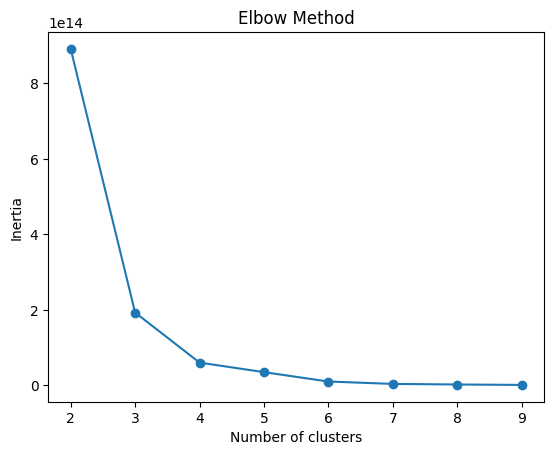

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# example: if using a dataframe df
X = df.select_dtypes(include='number')

inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [15]:
k = 4  # change based on elbow method

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

,original_code,original_name,translated_name,HCAT3_name,HCAT3_code,cluster
0,48,Mischung Mais/Bohne,Corn / bean mixture,grain_maize_corn_popcorn,3301010600,0
1,49,Blühmischung für Biogas,Flowering mixture for biogas,flowers_ornamental_plants,3301080000,0
2,50,Mischkulturen mit Saatgutmischung,Mixed cultures with seed mix,arable_land_seed_seedlings,3301100000,0
3,51,Mischkulturen in Reihenanbau,Mixed crops in rows,other_arable_land_crops,3301990000,0
4,52,Zwischenfrucht / Gründecke ÖVF,Intercrop / groundcover,other_arable_land_crops,3301990000,0


In [16]:
df["cluster"].value_counts()

cluster
0    322
3     39
1     33
2     27
Name: count, dtype: int64

In [18]:
print(hasattr(vectorizer, "vocabulary_"))

False


In [20]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)